# Delivery Performance Analysis

## Ziel

In diesem Notebook wird die Lieferperformance anhand der vorliegenden Logistikdaten untersucht. Ziel ist es, Lieferzeiten und Verspätungen zu analysieren und mögliche Unterschiede zwischen Regionen, Transportarten und Produkten zu identifizieren.

Dabei werden folgende Fragestellungen untersucht:

1. Wie lange dauern Lieferungen durchschnittlich?
2. Welche Regionen haben besonders lange Lieferzeiten?
3. Welche Transportarten sind besonders schnell bzw. langsam?
4. Wie häufig kommen Lieferungen verspätet an?
5. Gibt es bestimmte Regionen, Kunden oder Facilities mit überdurchschnittlich vielen Verspätungen?

Zur Beantwortung der Fragen werden die relevanten Tabellen zunächst zusammengeführt und anschließend bereinigt und analysiert. Die Ergebnisse werden durch geeignete Visualisierungen dargestellt.

## Datenbasis

Für die Analyse werden insbesondere folgende Tabellen verwendet:

- `loads` – Informationen zu den Sendungen
- `trips` – Informationen zu den durchgeführten Transporten
- `delivery_events` – Informationen zu Abholung und Lieferung
- `routes` – Informationen zu den jeweiligen Routen

Die Tabellen stehen in folgender Beziehung zueinander:

- `delivery_events`-(`trip_id`)->`trips`-(`load_id`)->`loads`-(`route_id`)->`routes`
- `delivery_events`-(`load_id`)->`loads`


## 1. Daten laden (über Pipeline)

In [1]:
import sys
sys.path.append("../src")

import pandas as pd
import matplotlib.pyplot as plt

from delivery_pipeline import run_pipeline

clean_df = run_pipeline()
print(f"Für die Analyse verwendete Loads: {len(clean_df)}")


2026-09-10 09:29:33,161 | INFO | loads: loaded 85410 rows, 12 columns
2026-09-10 09:29:33,575 | INFO | trips: loaded 85410 rows, 12 columns
2026-09-10 09:29:34,882 | INFO | delivery_events: loaded 170820 rows, 11 columns
2026-09-10 09:29:34,897 | INFO | routes: loaded 58 rows, 9 columns
2026-09-10 09:29:36,076 | INFO | Merged table: 170820 rows, 41 columns
2026-09-10 09:29:38,044 | INFO | Flattened to 85410 loads (from 170820 event rows)
2026-09-10 09:29:38,204 | INFO | Removed 486 loads with inconsistent timestamps (0.57%)
2026-09-10 09:29:44,604 | INFO | Saved cleaned data to D:\Documents\Portfolio\smart-logistics-analytics\data\processed\clean_delivery_performance.csv (84924 rows)


Für die Analyse verwendete Loads: 84924


*Hinweis zur Datenbereinigung: Loads, bei denen der tatsächliche Delivery-Zeitpunkt vor dem tatsächlichen Pickup-Zeitpunkt liegt, wurden bereits in der Pipeline ausgeschlossen (siehe `drop_inconsistent_timestamps()` in `delivery_pipeline.py`). Die Rohdaten bleiben davon unberührt, betroffen war weniger als 1 % der Loads.*

## 2. Lieferdauer und Pünktlichkeit

### 2.1 Wie lange dauern Lieferungen durchschnittlich?
### 2.2 Wie häufig kommen Lieferungen verspätet an?
### 2.3 Wie groß sind die Verspätungen?

## 1. Lieferdauer berechnen
Benötigte Spalten `pickup_actual_datetime` und `delivery_actual_datetime`
* `pickup_actual_datetime` < `delivery_actual_datetime` für alle `load_id`
* Erstellung neuer Spalte `delivery_duration_hours`
* Berechnung `delivery_duration_hours` = `delivery_actual_datetime` - `pickup_actual_datetime`
* Vergleich der berechneten Daten mit der bereits vorhandenen Spalte `actual_duration_hours` 

In [2]:
delayed_trips = clean_df[clean_df["is_delayed_delivery"]]
share_delayed = clean_df["is_delayed_delivery"].mean() * 100

print("### Lieferdauer")
display(clean_df["delivery_duration_hours"].describe().round(2))

print(f"\n### Pünktlichkeit ({len(clean_df)} Lieferungen gesamt)")
print(f"Verspätete Lieferungen: {clean_df['is_delayed_delivery'].sum()} ({share_delayed:.2f}%)")

print("\n### Verspätungsdauer (nur verspätete Lieferungen)")
display(delayed_trips["delivery_delay_hours"].describe().round(2))

### Lieferdauer


count    84924.00
mean        26.68
std         14.32
min          0.00
25%         14.62
50%         24.88
75%         38.53
max         73.77
Name: delivery_duration_hours, dtype: float64


### Pünktlichkeit (84924 Lieferungen gesamt)
Verspätete Lieferungen: 56933 (67.04%)

### Verspätungsdauer (nur verspätete Lieferungen)


count    56933.00
mean         3.00
std          1.74
min          0.01
25%          1.51
50%          3.00
75%          4.51
max          6.00
Name: delivery_delay_hours, dtype: float64

## 3. Grafiken

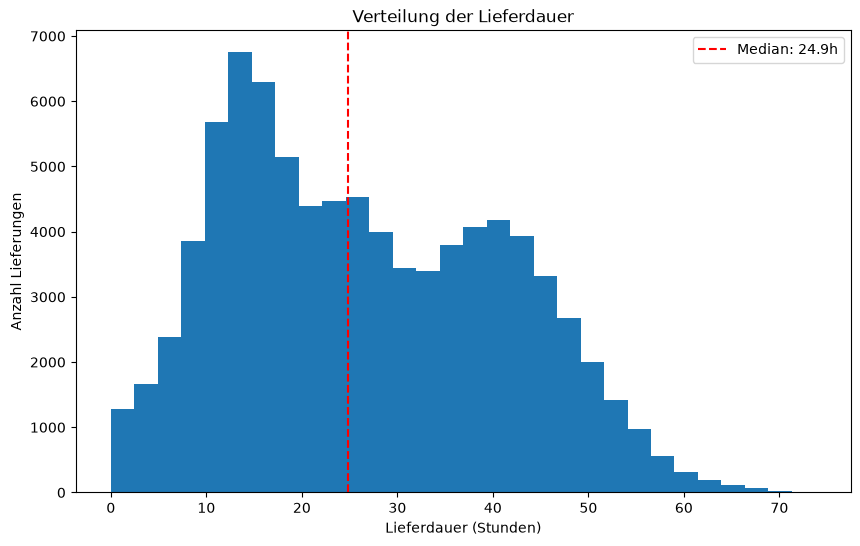

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(clean_df["delivery_duration_hours"], bins=30)
ax.axvline(
    clean_df["delivery_duration_hours"].median(),
    color="red", linestyle="--",
    label=f"Median: {clean_df['delivery_duration_hours'].median():.1f}h",
)
ax.set_xlabel("Lieferdauer (Stunden)")
ax.set_ylabel("Anzahl Lieferungen")
ax.set_title("Verteilung der Lieferdauer")
ax.legend()
plt.show()

*[Platzhalter Interpretation]*

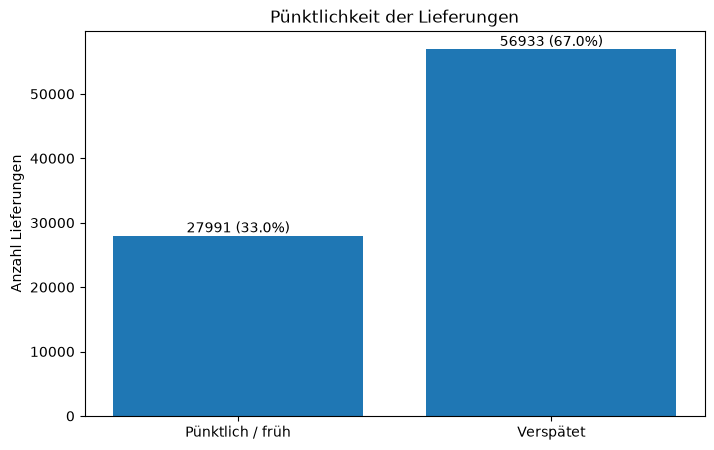

In [4]:
delay_counts = clean_df["is_delayed_delivery"].value_counts()
labels = ["Pünktlich / früh", "Verspätet"]
values = [delay_counts.get(False, 0), delay_counts.get(True, 0)]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, values)
ax.bar_label(bars, labels=[f"{v} ({v/sum(values)*100:.1f}%)" for v in values])
ax.set_ylabel("Anzahl Lieferungen")
ax.set_title("Pünktlichkeit der Lieferungen")
plt.show()

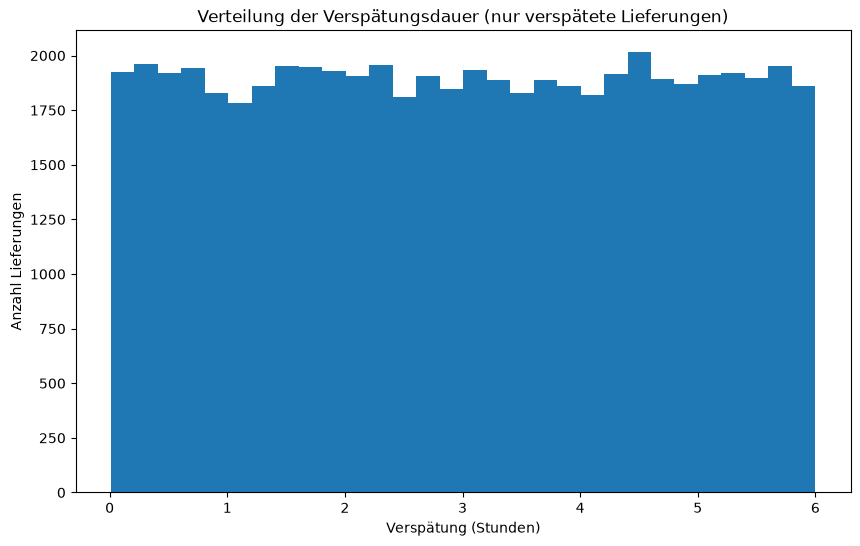

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(delayed_trips["delivery_delay_hours"], bins=30)
ax.set_xlabel("Verspätung (Stunden)")
ax.set_ylabel("Anzahl Lieferungen")
ax.set_title("Verteilung der Verspätungsdauer (nur verspätete Lieferungen)")
plt.show()

*[Platzhalter Interpretation]*

## 4. Regionale Unterschiede

### 4.1 Welche Regionen haben besonders lange Lieferzeiten und überdurchschnittlich viele Verspätungen?

In [6]:
region_stats = (
    clean_df.groupby("delivery_location_state")
    .agg(
        avg_duration_hours=("delivery_duration_hours", "mean"),
        delayed_share=("is_delayed_delivery", "mean"),
        n_loads=("load_id", "size"),
    )
    .round(2)
    .sort_values("delayed_share", ascending=False)
)
display(region_stats)

,avg_duration_hours,delayed_share,n_loads
delivery_location_state,,,
NY,28.35,0.71,4255
PA,20.77,0.70,5894
MO,18.90,0.68,5889
CA,30.53,0.67,8948
CO,23.87,0.67,5863
IN,20.49,0.67,5810
NV,32.99,0.67,1479
TX,27.42,0.67,7277
MN,17.44,0.67,4424


*[Platzhalter Interpretation]*

## 5. Unterschiede nach Transportart

### 5.1 Welche Transportarten sind besonders schnell bzw. langsam, welche besonders zuverlässig?

In [ ]:
transport_column = "load_type" 

#if transport_column in clean_df.columns:
mode_stats = (
    clean_df.groupby(transport_column)
    .agg(
        avg_duration_hours=("delivery_duration_hours", "mean"),
        delayed_share=("is_delayed_delivery", "mean"),
        n_loads=("load_id", "size"),
    )
    .round(2)
    .sort_values("delayed_share", ascending=False)
)  
display(mode_stats)
#else:
 #   print(f"Spalte '{transport_column}' nicht in clean_df vorhanden - Spaltennamen oben anpassen.")

,avg_duration_hours,delayed_share,n_loads
load_type,,,
Dry Van,26.70,0.67,42216
Refrigerated,26.66,0.67,42708


*[Platzhalter Interpretation]*

## 6. Fazit

*[Kurze Zusammenfassung der wichtigsten Erkenntnisse zu den eingangs gestellten Fragen]*